Magnetic Resonance Imaging (MRI) does not directly acquire images. Instead, it measures samples of the object's spatial frequency representation, known as k-space. The image is reconstructed by applying the inverse Fourier Transform to the acquired k-space data.

This study investigates the relationship between image space and k-space by examining how different spatial frequency components contribute to the reconstructed image.

In [ ]:
from src.phantom import generate_shepp_logan

from src.image_utils import (
    display_image,
    compare_images
)

from src.fft import (
    fft2c,
    ifft2c,
    magnitude,
    phase
)

from src.kspace import (
    log_magnitude,
    center_crop,
    remove_center,
    remove_edges,
    energy
)

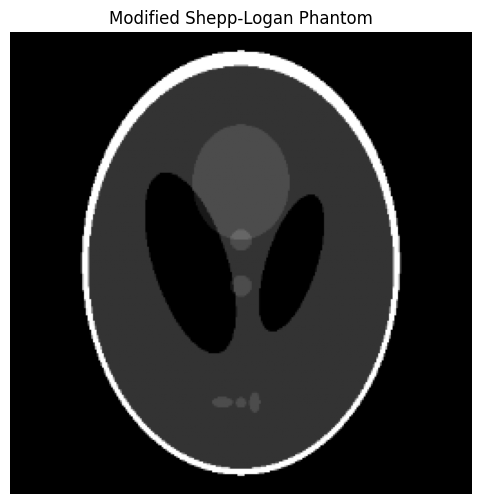

In [ ]:
# Generate the Modified Shepp-Logan phantom
phantom = generate_shepp_logan(size=256)

# Display the phantom
display_image(
    image=phantom,
    title="Modified Shepp-Logan Phantom"
)

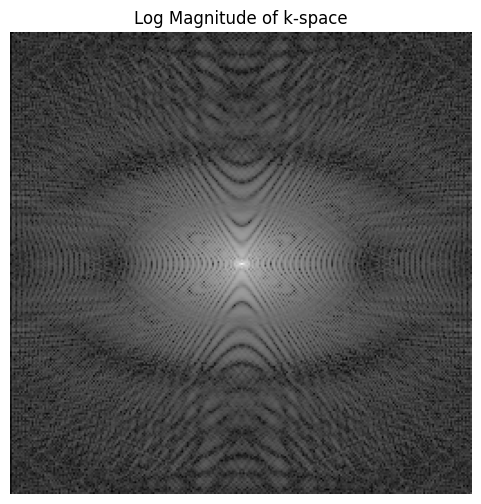

In [ ]:
# Compute the centered 2D Fourier Transform
kspace = fft2c(phantom)

# Display the log-scaled magnitude of k-space
display_image(
    image=log_magnitude(kspace),
    title="Log Magnitude of k-space"
)

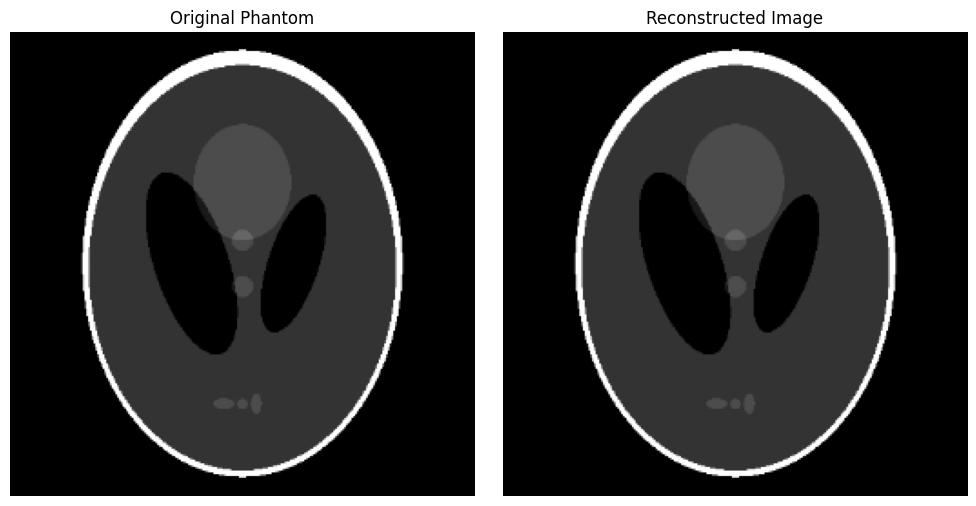

In [ ]:
# Reconstruct the image using the inverse Fourier Transform
reconstructed = magnitude(
    ifft2c(kspace)
)

# Compare the original phantom with the reconstructed image
compare_images(
    image1=phantom,
    image2=reconstructed,
    title1="Original Phantom",
    title2="Reconstructed Image"
)

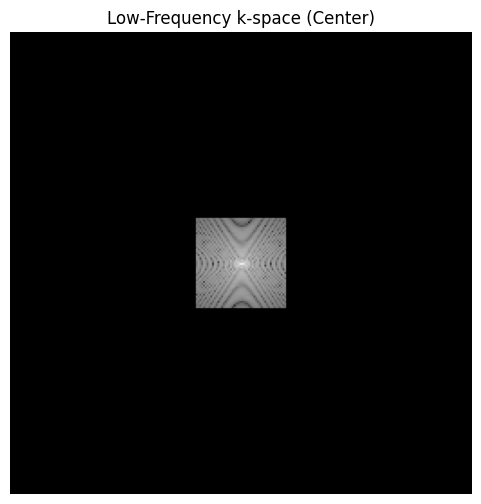

In [ ]:
# Keep only the low spatial frequencies (center of k-space)
low_frequency = center_crop(
    kspace,
    fraction=0.20
)

# Display the retained low-frequency k-space
display_image(
    image=log_magnitude(low_frequency),
    title="Low-Frequency k-space (Center)"
)

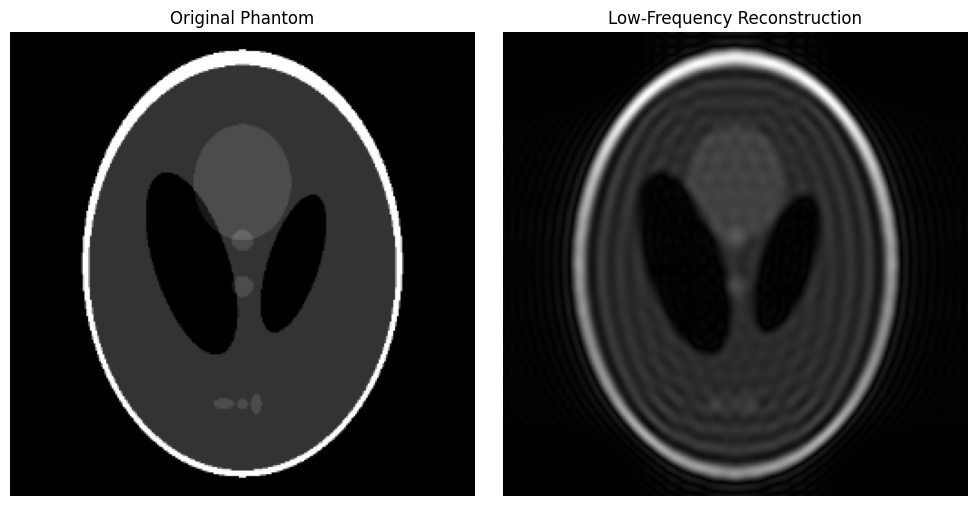

In [ ]:
# Reconstruct the image using only the low spatial frequencies
low_image = magnitude(
    ifft2c(low_frequency)
)

# Compare the original phantom with the low-frequency reconstruction
compare_images(
    image1=phantom,
    image2=low_image,
    title1="Original Phantom",
    title2="Low-Frequency Reconstruction"
)

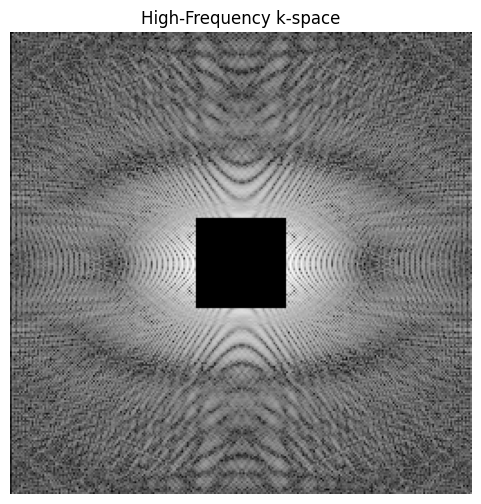

In [ ]:
# Remove the low spatial frequencies (center of k-space)
high_frequency = remove_center(
    kspace,
    fraction=0.20
)

# Display the remaining high-frequency k-space
display_image(
    image=log_magnitude(high_frequency),
    title="High-Frequency k-space"
)

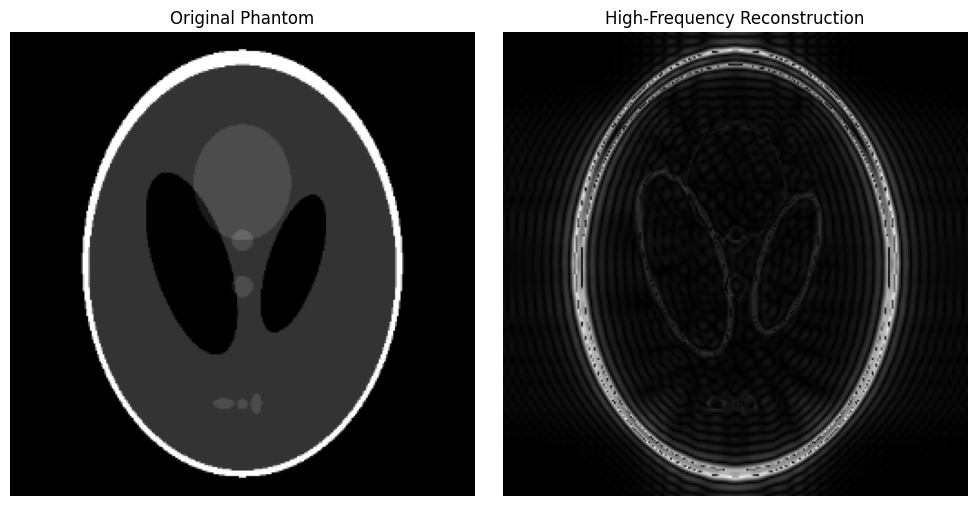

In [ ]:
# Reconstruct the image using only the high spatial frequencies
high_image = magnitude(
    ifft2c(high_frequency)
)

# Compare the original phantom with the high-frequency reconstruction
compare_images(
    image1=phantom,
    image2=high_image,
    title1="Original Phantom",
    title2="High-Frequency Reconstruction"
)

In [ ]:
print(f"Original energy: {energy(kspace):.2f}")
print(f"Low-frequency energy: {energy(low_frequency):.2f}")
print(f"High-frequency energy: {energy(high_frequency):.2f}")

## Discussion

This investigation demonstrates the fundamental relationship between image space and k-space in MRI. The centered Fourier Transform maps the spatial image into its spatial frequency representation, where low spatial frequencies are concentrated near the center of k-space and high spatial frequencies occupy the periphery.

Retaining only the central region of k-space preserves the overall image contrast and anatomical structures but removes fine spatial details, resulting in a blurred reconstruction. In contrast, removing the central frequencies suppresses the dominant image intensity while emphasizing edges and fine structural features associated with high spatial frequencies.

The near-perfect reconstruction obtained from the complete k-space confirms that the centered Fourier Transform and its inverse provide a lossless numerical transformation, aside from negligible floating-point precision errors. These observations establish the fundamental role of k-space in MRI and provide the theoretical basis for subsequent investigations of undersampling, non-Cartesian acquisition, and image reconstruction.